# Sentiment Analysis — BERT-based LLMs
**Dataset:** cardiffnlp/tweet_eval (SemEval-2017)  
**Models:** XLM-RoBERTa · mBERT · DistilBERT-multilingual  
**Tracking:** Weights & Biases  
**Environment:** macOS osx-arm64, Apple M4 Pro, Python 3.12

In [57]:
# Necessary imports
import os, time, json, random, warnings
warnings.filterwarnings('ignore')

from dotenv import load_dotenv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn

from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score,
)

from datasets import Dataset, DatasetDict, load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    pipeline,
)
from peft import LoraConfig, get_peft_model, TaskType, PeftModel
import evaluate
import wandb

print(f"PyTorch : {torch.__version__}")
print(f"MPS     : {torch.backends.mps.is_available()}")
print(f"CUDA    : {torch.cuda.is_available()}")

PyTorch : 2.12.0
MPS     : True
CUDA    : False


In [58]:
load_dotenv()

WANDB_API_KEY = os.getenv("WANDB_API_KEY")
wandb.login(key=WANDB_API_KEY)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /Users/julianyoo/.netrc


True

In [59]:
# Model registry
BASE_MODEL_NAME   = "xlm-roberta-base"
STREAM_MODEL_NAME = "distilbert-base-multilingual-cased"
MODELS = {
    "xlm-roberta"  : "xlm-roberta-base",
    "mbert"        : "bert-base-multilingual-cased",
    "distilbert-ml": "distilbert-base-multilingual-cased",
}

# Training
MAX_LENGTH      = 64
BATCH_SIZE      = 32
NUM_EPOCHS      = 3
LEARNING_RATE   = 2e-5
WEIGHT_DECAY    = 0.01
WARMUP_RATIO    = 0.06
TRAIN_SUBSAMPLE = 0.25
SEED            = 42

# LoRA
LORA_R       = 16
LORA_ALPHA   = 32
LORA_DROPOUT = 0.1
LORA_LR      = 3e-4
LORA_TARGETS = {
    "xlm-roberta"  : ["query", "value"],
    "mbert"        : ["query", "value"],
    "distilbert-ml": ["q_lin", "v_lin"],
}

# WandB
WANDB_PROJECT = "sentiment-analysis-bert"
WANDB_ENTITY  = "jskyoo" # wandb username

# Outputs
os.makedirs("./outputs", exist_ok=True)
os.makedirs("./outputs/reports", exist_ok=True)

# Device
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"Active device   : {DEVICE}")
print(f"MAX_LENGTH      : {MAX_LENGTH}")
print(f"BATCH_SIZE      : {BATCH_SIZE}")
print(f"NUM_EPOCHS      : {NUM_EPOCHS}")
print(f"TRAIN_SUBSAMPLE : {TRAIN_SUBSAMPLE}")

Active device   : mps
MAX_LENGTH      : 64
BATCH_SIZE      : 32
NUM_EPOCHS      : 3
TRAIN_SUBSAMPLE : 0.25


In [60]:
try:
    wandb.login()
    WANDB_ENABLED = True
    print("WandB login successful")
except Exception as e:
    print(f"WandB unavailable ({e}) — logging disabled")
    WANDB_ENABLED = False

WandB login successful


## Data Loading — cardiffnlp/tweet_eval
SemEval-2017 Task 4A. Real human-annotated tweets.  
Pre-defined train/val/test splits — **do not re-split**.  
Labels: 0=negative, 1=neutral, 2=positive

In [61]:
print("Loading cardiffnlp/tweet_eval (sentiment)...")
raw_en = load_dataset("cardiffnlp/tweet_eval", "sentiment")
print(raw_en)

_label_map = {0: 'negative', 1: 'neutral', 2: 'positive'}

train_df = pd.DataFrame({
    "Text"     : raw_en["train"]["text"],
    "Sentiment": [_label_map[l] for l in raw_en["train"]["label"]],
})
val_df = pd.DataFrame({
    "Text"     : raw_en["validation"]["text"],
    "Sentiment": [_label_map[l] for l in raw_en["validation"]["label"]],
})
test_df = pd.DataFrame({
    "Text"     : raw_en["test"]["text"],
    "Sentiment": [_label_map[l] for l in raw_en["test"]["label"]],
})

for _df in [train_df, val_df, test_df]:
    _df["Text"]      = _df["Text"].astype(str).str.strip()
    _df["Sentiment"] = _df["Sentiment"].str.lower().str.strip()

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Full train : {len(train_df)}")
print(f"Val        : {len(val_df)}")
print(f"Test       : {len(test_df)}")
print("\nTrain distribution:")
print(train_df["Sentiment"].value_counts())

Loading cardiffnlp/tweet_eval (sentiment)...
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})
Full train : 45615
Val        : 2000
Test       : 12284

Train distribution:
Sentiment
neutral     20673
positive    17849
negative     7093
Name: count, dtype: int64


Subsampled train size : 11403


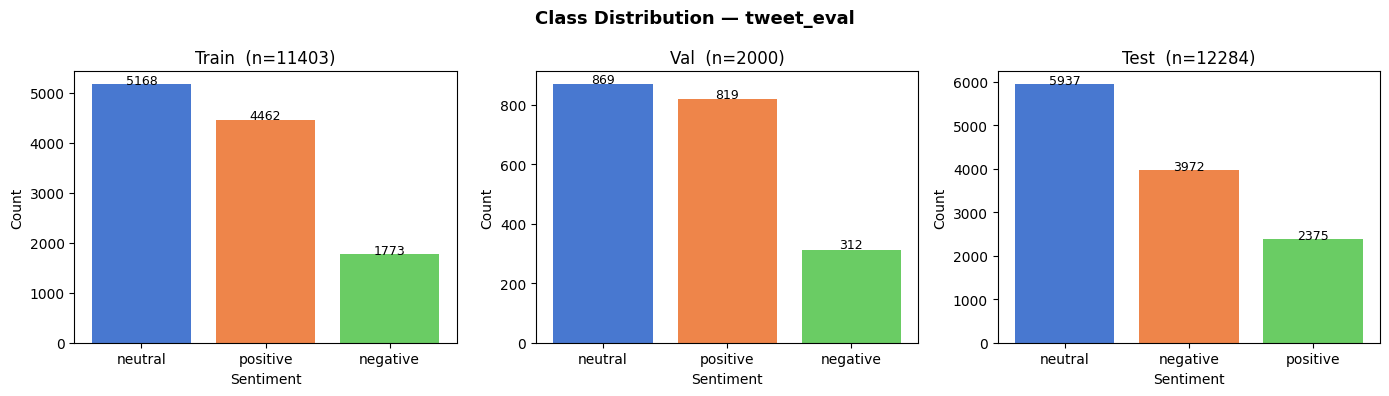

In [62]:
# Subsample training set
if TRAIN_SUBSAMPLE < 1.0:
    train_df, _ = train_test_split(
        train_df, train_size=TRAIN_SUBSAMPLE,
        stratify=train_df["Sentiment"], random_state=SEED
    )
    train_df = train_df.reset_index(drop=True)

print(f"Subsampled train size : {len(train_df)}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Class Distribution — tweet_eval", fontsize=13, fontweight="bold")
for ax, (name, df_) in zip(
    axes,
    [("Train", train_df), ("Val", val_df), ("Test", test_df)]
):
    counts = df_["Sentiment"].value_counts()
    ax.bar(counts.index, counts.values,
           color=sns.color_palette('muted', len(counts)))
    ax.set_title(f"{name}  (n={len(df_)})")
    ax.set_xlabel("Sentiment")
    ax.set_ylabel("Count")
    for bar, val in zip(ax.patches, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 5, str(val), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig("./outputs/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Preprocessing & Tokenisation

In [63]:
unique_labels = sorted(train_df["Sentiment"].unique())
label2id      = {label: idx  for idx, label in enumerate(unique_labels)}
id2label      = {idx:  label for label, idx  in label2id.items()}
NUM_LABELS    = len(unique_labels)

train_df["label"] = train_df["Sentiment"].map(label2id)
val_df["label"]   = val_df["Sentiment"].map(label2id)
test_df["label"]  = test_df["Sentiment"].map(label2id)

print(f"Classes  : {NUM_LABELS}")
print(f"label2id : {label2id}")

Classes  : 3
label2id : {'negative': 0, 'neutral': 1, 'positive': 2}


In [64]:
# Verify MAX_LENGTH=64 covers the dataset
_tok_check = AutoTokenizer.from_pretrained(BASE_MODEL_NAME)
sample_lengths = [
    len(_tok_check.encode(t, add_special_tokens=True))
    for t in train_df["Text"].sample(1000, random_state=SEED)
]
print(f"Token length stats (1000-sample):")
print(f"  Mean   : {np.mean(sample_lengths):.1f}")
print(f"  Median : {np.median(sample_lengths):.1f}")
print(f"  95th % : {np.percentile(sample_lengths, 95):.1f}")
print(f"  99th % : {np.percentile(sample_lengths, 99):.1f}")
print(f"  Max    : {max(sample_lengths)}")
covered = sum(l <= MAX_LENGTH for l in sample_lengths) / len(sample_lengths)
print(f"  MAX_LENGTH={MAX_LENGTH} covers {covered*100:.1f}% of samples")

Token length stats (1000-sample):
  Mean   : 31.4
  Median : 31.0
  95th % : 45.0
  99th % : 55.0
  Max    : 65
  MAX_LENGTH=64 covers 99.9% of samples


In [65]:
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_NAME)

def make_tokenized_dataset(
    model_name: str,
) -> tuple:
    """
    Build a per-model tokenized DatasetDict.
    Must be called per model — each uses its own tokenizer.
    """
    tok = AutoTokenizer.from_pretrained(model_name)
    ds = DatasetDict({
        "train": Dataset.from_pandas(
            train_df[["Text", "label"]], preserve_index=False),
        "val"  : Dataset.from_pandas(
            val_df[["Text",   "label"]], preserve_index=False),
        "test" : Dataset.from_pandas(
            test_df[["Text",  "label"]], preserve_index=False),
    })

    def _tok_fn(batch):
        return tok(
            batch["Text"],
            padding="max_length",
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors=None,
        )

    tokenized_ds = ds.map(
        _tok_fn, batched=True, batch_size=512,
        remove_columns=["Text"],
        desc=f"Tokenising [{model_name.split("/")[-1]}]",
    )
    tokenized_ds.set_format(
        type="torch", columns=["input_ids", "attention_mask", "label"]
    )
    return tokenized_ds, tok

tokenized, _ = make_tokenized_dataset(BASE_MODEL_NAME)
print(f"Features : {tokenized["train"].features}")
print(f"Shape    : {tokenized["train"]["input_ids"][0].shape}")

Tokenising [xlm-roberta-base]: 100%|██████████| 12284/12284 [00:00<00:00, 56211.18 examples/s]

Features : {'label': Value('int64'), 'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8'))}
Shape    : torch.Size([64])


## Model Utilities

In [66]:
def load_base_model(
    model_name: str = BASE_MODEL_NAME,
) -> AutoModelForSequenceClassification:
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=NUM_LABELS,
        id2label=id2label,
        label2id=label2id,
    )
    return model.to(DEVICE)


def count_params(model) -> str:
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    return (
        f"  Trainable : {trainable:>12,}\n"
        f"  Total     : {total:>12,}\n"
        f"  Rate      : {100 * trainable / total:.2f}%"
    )


accuracy_metric = evaluate.load("accuracy")
f1_metric       = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(
        predictions=preds, references=labels)["accuracy"]
    f1  = f1_metric.compute(
        predictions=preds, references=labels, average="macro")["f1"]
    return {"accuracy": acc, "f1_macro": f1}


label_counts  = train_df["label"].value_counts().sort_index()
class_weights = torch.tensor(
    [len(train_df) / (NUM_LABELS * label_counts[i])
     for i in range(NUM_LABELS)],
    dtype=torch.float32,
).to(DEVICE)

print("Class weights (inverse frequency):")
for i, w in enumerate(class_weights):
    print(f"  {id2label[i]:<12} : {w:.4f}")

Class weights (inverse frequency):
  negative     : 2.1438
  neutral      : 0.7355
  positive     : 0.8519


## Zero-Shot Baseline
Untrained classification head — random-weight baseline.

In [67]:
base_model = load_base_model()
print(count_params(base_model))

def zero_shot_inference(
    model, tokenizer_, texts: list, device=DEVICE
) -> list:
    model.eval()
    preds = []
    with torch.no_grad():
        for text in texts:
            enc = tokenizer_(
                text, return_tensors='pt',
                truncation=True, max_length=MAX_LENGTH, padding=True,
            ).to(device)
            pred_id = model(**enc).logits.argmax(dim=-1).item()
            preds.append(id2label[pred_id])
    return preds

demo_n      = min(10, len(test_df))
demo_texts  = test_df["Text"].tolist()[:demo_n]
demo_labels = test_df["Sentiment"].tolist()[:demo_n]
base_preds  = zero_shot_inference(base_model, tokenizer, demo_texts)

print("\nZero-shot Baseline - XLM-RoBERTa")
print("-" * 60)
for i, (text, true, pred) in enumerate(
    zip(demo_texts, demo_labels, base_preds)
):
    status = "V" if pred == true else "X"
    print(f"[{i+1:02d}] {status} True:{true:<12} Pred:{pred:<12}")
    print(f"     {text[:80]}")
    print()

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 7808.11it/s]
[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Trainable :  278,045,955
  Total     :  278,045,955
  Rate      : 100.00%

Zero-shot Baseline - XLM-RoBERTa
------------------------------------------------------------
[01] X True:neutral      Pred:negative    
     @user @user what do these '1/2 naked pics' have to do with anything? They're not

[02] X True:neutral      Pred:negative    
     OH: “I had a blue penis while I was this” [playing with Google Earth VR]

[03] X True:neutral      Pred:negative    
     @user @user That's coming, but I think the victims are going to be Medicaid reci

[04] X True:positive     Pred:negative    
     I think I may be finally in with the in crowd #mannequinchallenge  #grads2014 @u

[05] V True:negative     Pred:negative    
     @user Wow,first Hugo Chavez and now Fidel Castro. Danny Glover, Michael Moore, O

[06] X True:neutral      Pred:negative    
     Savchenko now Saakashvili took drug test live on Ukraine TV. To prove they are n

[07] X True:neutral      Pred:negative    
     How many 

## Few-Shot Inference
BERT few-shot via CLS embedding similarity:
1. Extract `[CLS]` embeddings for K examples per class
2. Average into class centroid (prototype)
3. Classify queries by cosine similarity to centroids

In [68]:
def extract_cls_embeddings(
    model, tokenizer_, texts: list,
    device=DEVICE, batch_size: int = 32,
) -> torch.Tensor:
    model.eval()
    all_embeddings = []
    if hasattr(model, 'roberta'):
        encoder = model.roberta
    elif hasattr(model, 'bert'):
        encoder = model.bert
    elif hasattr(model, 'distilbert'):
        encoder = model.distilbert
    else:
        raise ValueError('Unknown architecture')
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            enc = tokenizer_(
                texts[i:i+batch_size], return_tensors='pt',
                padding=True, truncation=True, max_length=MAX_LENGTH,
            ).to(device)
            cls_emb = encoder(**enc).last_hidden_state[:, 0, :]
            all_embeddings.append(cls_emb.cpu())
    return torch.cat(all_embeddings, dim=0)


def build_prototypes(
    model, tokenizer_, support_df: pd.DataFrame, k_shots: int
) -> tuple:
    class_embeddings = {}
    for label_str in unique_labels:
        rows   = support_df[support_df["Sentiment"] == label_str]
        sample = rows.sample(min(k_shots, len(rows)), random_state=SEED)
        embs   = extract_cls_embeddings(model, tokenizer_, sample["Text"].tolist())
        class_embeddings[label_str] = embs.mean(dim=0)
    proto_labels = list(class_embeddings.keys())
    prototypes   = torch.stack([class_embeddings[l] for l in proto_labels])
    return prototypes, proto_labels


def prototype_predict(
    model, tokenizer_, query_texts: list,
    prototypes: torch.Tensor, proto_labels: list,
) -> list:
    q_embs = extract_cls_embeddings(model, tokenizer_, query_texts)
    q_norm = torch.nn.functional.normalize(q_embs, dim=-1)
    p_norm = torch.nn.functional.normalize(prototypes, dim=-1)
    pred_idxs = (q_norm @ p_norm.T).argmax(dim=-1).tolist()
    return [proto_labels[i] for i in pred_idxs]


few_shot_results = {}
query_texts  = test_df["Text"].tolist()[:50]
query_labels = test_df["Sentiment"].tolist()[:50]
support_df   = train_df.copy()

for k in [1, 3, 5]:
    protos, proto_labels = build_prototypes(
        base_model, tokenizer, support_df, k_shots=k
    )
    preds = prototype_predict(
        base_model, tokenizer, query_texts, protos, proto_labels
    )
    acc = accuracy_score(query_labels, preds)
    few_shot_results[f"{k}-shot"] = acc
    print(f"  {k}-shot accuracy : {acc:.4f}")

print("\nFew-Shot Summary:")
for k_str, acc in few_shot_results.items():
    print(f"  {k_str} : {acc:.4f}")

  1-shot accuracy : 0.5000
  3-shot accuracy : 0.3200
  5-shot accuracy : 0.4200

Few-Shot Summary:
  1-shot : 0.5000
  3-shot : 0.3200
  5-shot : 0.4200


## Custom Trainers (Collapse Prevention)
- **FocalLossTrainer** — Full FT: `FL = -(1-pt)^gamma * CE`
- **WeightedTrainer** — LoRA: inverse-frequency class weights

In [69]:
class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights: torch.Tensor, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels")
        outputs = model(**inputs)
        loss_fn = nn.CrossEntropyLoss(
            weight=self.class_weights.to(outputs.logits.device)
        )
        loss = loss_fn(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss


class FocalLossTrainer(Trainer):
    def __init__(self, *args, gamma: float = 2.0,
                 class_weights: torch.Tensor = None, **kwargs):
        super().__init__(*args, **kwargs)
        self.gamma         = gamma
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels")
        outputs = model(**inputs)
        ce_fn   = nn.CrossEntropyLoss(
            weight=self.class_weights.to(outputs.logits.device)
            if self.class_weights is not None else None,
            reduction="none",
        )
        ce_loss = ce_fn(outputs.logits, labels)
        loss    = ((1 - torch.exp(-ce_loss)) ** self.gamma * ce_loss).mean()
        return (loss, outputs) if return_outputs else loss


print("Custom trainers defined.")

Custom trainers defined.


In [70]:
# Helper functions for report
def save_classification_report_md(
    true_ids, pred_ids, model_key: str, method: str,
    test_res: dict, training_time_s: float,
) -> str:
    """
    Save a full classification report as a .md file and return the string.
    """
    report = classification_report(
        true_ids, pred_ids, target_names=unique_labels, digits=4
    )
    acc  = test_res["eval_accuracy"]
    f1   = test_res["eval_f1_macro"]
    loss = test_res["eval_loss"]
    mins = int(training_time_s // 60)
    secs = int(training_time_s % 60)

    md = (
        f"# Classification Report: {model_key} ({method})\n\n"
        f"## Summary\n"
        f"| Metric | Value |\n"
        f"|--------|-------|\n"
        f"| Accuracy | {acc:.4f} |\n"
        f"| F1-Macro | {f1:.4f} |\n"
        f"| Eval Loss | {loss:.4f} |\n"
        f"| Training Time | {mins}m {secs}s |\n\n"
        f"## Configuration\n"
        f"| Parameter | Value |\n"
        f"|-----------|-------|\n"
        f"| Model | {MODELS[model_key]} |\n"
        f"| Method | {method} |\n"
        f"| MAX_LENGTH | {MAX_LENGTH} |\n"
        f"| BATCH_SIZE | {BATCH_SIZE} |\n"
        f"| NUM_EPOCHS | {NUM_EPOCHS} |\n"
        f"| LEARNING_RATE | {LEARNING_RATE} |\n"
        f"| TRAIN_SUBSAMPLE | {TRAIN_SUBSAMPLE} |\n"
        f"| Train samples | {len(train_df)} |\n\n"
        f"## Detailed Classification Report\n"
        f"```\n{report}```\n"
    )

    safe_method = method.replace(' ', '_')
    fname = f"./outputs/reports/{model_key}_{safe_method}.md"
    with open(fname, 'w') as f:
        f.write(md)
    print(f"  Report saved: {fname}")
    return md


print("save_classification_report_md() defined.")

save_classification_report_md() defined.


## Model training

In [71]:
def _make_training_args(out_dir: str, lr: float, run_name: str) -> TrainingArguments:
    return TrainingArguments(
        output_dir                  = out_dir,
        num_train_epochs            = NUM_EPOCHS,
        per_device_train_batch_size = BATCH_SIZE,
        per_device_eval_batch_size  = BATCH_SIZE * 2,
        learning_rate               = lr,
        weight_decay                = WEIGHT_DECAY,
        warmup_ratio                = WARMUP_RATIO,
        max_grad_norm               = 1.0,
        eval_strategy               = "steps",
        eval_steps                  = 200,
        save_strategy               = "steps",
        save_steps                  = 200,
        load_best_model_at_end      = True,
        metric_for_best_model       = "f1_macro",
        greater_is_better           = True,
        logging_steps               = 50,
        report_to                   = "wandb" if WANDB_ENABLED else "none",
        run_name                    = run_name,
        seed                        = SEED,
        fp16                        = False,
        bf16                        = False,
        dataloader_num_workers      = 0,
        push_to_hub                 = False,
    )

print("_make_training_args() defined.")

_make_training_args() defined.


## Fine-Tuning Functions (Full and LoRA)

In [72]:
def run_full_finetune(
    model_key: str, model_name: str, tokenized_ds
) -> dict:
    run_name = f"{model_key}_fullft"
    print(f"\n{'-'*60}")
    print(f"  Full FT : {model_key} ({model_name})")
    print(f"{'-'*60}")

    if WANDB_ENABLED:
        wandb.init(
            project = WANDB_PROJECT,
            entity  = WANDB_ENTITY,
            name    = run_name,
            config  = {
                "model"       : model_name,
                "method"      : "Full FT",
                "max_length"  : MAX_LENGTH,
                "batch_size"  : BATCH_SIZE,
                "epochs"      : NUM_EPOCHS,
                "lr"          : LEARNING_RATE,
                "lora"        : False,
                "subsample"   : TRAIN_SUBSAMPLE,
            },
            reinit = "finish_previous",
        )

    model   = load_base_model(model_name)
    out_dir = f"./outputs/{model_key}_fullft"
    os.makedirs(out_dir, exist_ok=True)
    print(count_params(model))

    trainer = FocalLossTrainer(
        model           = model,
        args            = _make_training_args(out_dir, LEARNING_RATE, run_name),
        train_dataset   = tokenized_ds["train"],
        eval_dataset    = tokenized_ds["val"],
        compute_metrics = compute_metrics,
        gamma           = 2.0,
        class_weights   = class_weights,
        callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)],
    )

    t0 = time.time()
    trainer.train()
    training_time = time.time() - t0
    print(f"  Training time : {training_time/60:.1f} min ({training_time:.0f}s)")

    trainer.save_model(f"{out_dir}/best")

    test_res = trainer.evaluate(tokenized_ds["test"])
    pred_out = trainer.predict(tokenized_ds["test"])
    pred_ids = np.argmax(pred_out.predictions, axis=-1)
    true_ids = pred_out.label_ids

    print(f"  Test Accuracy : {test_res['eval_accuracy']:.4f}")
    print(f"  Test F1-Macro : {test_res['eval_f1_macro']:.4f}")

    md = save_classification_report_md(
        true_ids, pred_ids, model_key, 'Full FT', test_res, training_time
    )
    print(md)

    if WANDB_ENABLED:
        wandb.log({
            "test/accuracy"   : test_res["eval_accuracy"],
            "test/f1_macro"   : test_res["eval_f1_macro"],
            "test/loss"       : test_res["eval_loss"],
            "training_time_s" : training_time,
        })
        wandb.finish()

    return {
        "model_key"     : model_key,
        "method"        : "Full FT",
        "test_results"  : test_res,
        "pred_ids"      : pred_ids,
        "true_ids"      : true_ids,
        "training_time" : training_time,
    }


print("run_full_finetune() defined.")

run_full_finetune() defined.


In [73]:
def run_lora_finetune(
    model_key: str, model_name: str, tokenized_ds
) -> dict:
    run_name = f"{model_key}_lora"
    print(f"\n{'-'*60}")
    print(f"  LoRA : {model_key} ({model_name})")
    print(f"{'-'*60}")

    if WANDB_ENABLED:
        wandb.init(
            project = WANDB_PROJECT,
            entity  = WANDB_ENTITY,
            name    = run_name,
            config  = {
                "model"       : model_name,
                "method"      : "LoRA",
                "max_length"  : MAX_LENGTH,
                "batch_size"  : BATCH_SIZE,
                "epochs"      : NUM_EPOCHS,
                "lr"          : LORA_LR,
                "lora_r"      : LORA_R,
                "lora_alpha"  : LORA_ALPHA,
                "lora"        : True,
                "subsample"   : TRAIN_SUBSAMPLE,
            },
            reinit = True,
        )

    base    = load_base_model(model_name)
    out_dir = f"./outputs/{model_key}_lora"
    os.makedirs(out_dir, exist_ok=True)

    model = get_peft_model(base, LoraConfig(
        r              = LORA_R,
        lora_alpha     = LORA_ALPHA,
        target_modules = LORA_TARGETS[model_key],
        lora_dropout   = LORA_DROPOUT,
        bias           = "none",
        task_type      = TaskType.SEQ_CLS,
        inference_mode = False,
    ))
    print(count_params(model))
    model.print_trainable_parameters()

    trainer = WeightedTrainer(
        model           = model,
        args            = _make_training_args(out_dir, LORA_LR, run_name),
        train_dataset   = tokenized_ds["train"],
        eval_dataset    = tokenized_ds["val"],
        compute_metrics = compute_metrics,
        class_weights   = class_weights,
        callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)],
    )

    t0 = time.time()
    trainer.train()
    training_time = time.time() - t0
    print(f"  Training time : {training_time/60:.1f} min ({training_time:.0f}s)")

    model.save_pretrained(f"{out_dir}/adapters")

    test_res = trainer.evaluate(tokenized_ds["test"])
    pred_out = trainer.predict(tokenized_ds["test"])
    pred_ids = np.argmax(pred_out.predictions, axis=-1)
    true_ids = pred_out.label_ids

    print(f"  Test Accuracy : {test_res['eval_accuracy']:.4f}")
    print(f"  Test F1-Macro : {test_res['eval_f1_macro']:.4f}")

    md = save_classification_report_md(
        true_ids, pred_ids, model_key, 'LoRA', test_res, training_time
    )
    print(md)

    if WANDB_ENABLED:
        wandb.log({
            "test/accuracy"   : test_res["eval_accuracy"],
            "test/f1_macro"   : test_res["eval_f1_macro"],
            "test/loss"       : test_res["eval_loss"],
            "training_time_s" : training_time,
        })
        wandb.finish()

    return {
        "model_key"     : model_key,
        "method"        : "LoRA",
        "test_results"  : test_res,
        "pred_ids"      : pred_ids,
        "true_ids"      : true_ids,
        "training_time" : training_time,
    }


print("run_lora_finetune() defined.")

run_lora_finetune() defined.


In [74]:
# Single cell — both Full FT and LoRA for all 3 models
# all_results accumulates correctly — no double-reset bug
all_results    = []
training_times = {}

for model_key, model_name in MODELS.items():
    print(f"\n{'#'*60}")
    print(f"  MODEL : {model_key.upper()}")
    print(f"  {model_name}")
    print(f"{'#'*60}")

    tokenized_ds, _ = make_tokenized_dataset(model_name)

    r_full = run_full_finetune(model_key, model_name, tokenized_ds)
    all_results.append(r_full)
    training_times[f"{model_key}_fullft"] = r_full['training_time']

    r_lora = run_lora_finetune(model_key, model_name, tokenized_ds)
    all_results.append(r_lora)
    training_times[f"{model_key}_lora"] = r_lora['training_time']

    if DEVICE.type == 'mps':
        torch.mps.empty_cache()

print("\nAll training complete.")
print("\nTraining time summary:")
for run, t in training_times.items():
    print(f"  {run:<30} {t/60:.1f} min")


############################################################
  MODEL : XLM-ROBERTA
  xlm-roberta-base
############################################################


Tokenising [xlm-roberta-base]: 100%|██████████| 12284/12284 [00:00<00:00, 51348.30 examples/s]



------------------------------------------------------------
  Full FT : xlm-roberta (xlm-roberta-base)
------------------------------------------------------------


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 15623.75it/s]
[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ra

  Trainable :  278,045,955
  Total     :  278,045,955
  Rate      : 100.00%


...

  Training time : 2.2 min (132s)


Training Loss,Validation Loss,Step,Accuracy,F1 Macro
0.706576,0.834832,1071,0.622191,0.619157


  Test Accuracy : 0.6222
  Test F1-Macro : 0.6192
  Report saved: ./outputs/reports/distilbert-ml_LoRA.md
# Classification Report: distilbert-ml (LoRA)

## Summary
| Metric | Value |
|--------|-------|
| Accuracy | 0.6222 |
| F1-Macro | 0.6192 |
| Eval Loss | 0.8348 |
| Training Time | 2m 11s |

## Configuration
| Parameter | Value |
|-----------|-------|
| Model | distilbert-base-multilingual-cased |
| Method | LoRA |
| MAX_LENGTH | 64 |
| BATCH_SIZE | 32 |
| NUM_EPOCHS | 3 |
| LEARNING_RATE | 2e-05 |
| TRAIN_SUBSAMPLE | 0.25 |
| Train samples | 11403 |

## Detailed Classification Report
```
              precision    recall  f1-score   support

    negative     0.5932    0.7082    0.6456      3972
     neutral     0.6867    0.5575    0.6154      5937
    positive     0.5584    0.6400    0.5964      2375

    accuracy                         0.6222     12284
   macro avg     0.6128    0.6352    0.6192     12284
weighted avg     0.6317    0.6222    0.6215     12284
```



eval/accuracy,▁▆▆█▆▇▇
eval/f1_macro,▁▆▆▇▆▇█
eval/loss,█▄▂▄▁▁▅
eval/runtime,▁▁▁▁▁▁█
eval/samples_per_second,██▅▂▂▁▂
eval/steps_per_second,██▅▂▃▂▁
test/accuracy,▁▁
test/f1_macro,▁▁
test/loss,▁▁
test/runtime,▁
+8,...



All training complete.

Training time summary:
  xlm-roberta_fullft             15.4 min
  xlm-roberta_lora               4.4 min
  mbert_fullft                   34.0 min
  mbert_lora                     4.3 min
  distilbert-ml_fullft           7.6 min
  distilbert-ml_lora             2.2 min


In [75]:
rows = []
for r in all_results:
    tr = r['test_results']
    rows.append({
        "Model"         : r["model_key"],
        "Method"        : r["method"],
        "Accuracy"      : round(tr["eval_accuracy"], 4),
        "F1-Macro"      : round(tr["eval_f1_macro"],  4),
        "Loss"          : round(tr["eval_loss"],       4),
        "Train Time(m)" : round(r["training_time"]/60, 1),
    })

comparison_df = pd.DataFrame(rows)
print(comparison_df.sort_values("F1-Macro", ascending=False).to_string(index=False))

try:
    comparison_df.sort_values("F1-Macro", ascending=False).to_markdown(
        "./outputs/reports/model_comparison.md", index=False
    )
    print("\nComparison table saved to ./outputs/reports/model_comparison.md")
except Exception:
    comparison_df.to_csv("./outputs/reports/model_comparison.csv", index=False)
    print("Comparison table saved as CSV (install tabulate for markdown)")

        Model  Method  Accuracy  F1-Macro   Loss  Train Time(m)
  xlm-roberta    LoRA    0.6596    0.6626 0.6428            4.4
  xlm-roberta Full FT    0.6552    0.6588 0.4130           15.4
        mbert    LoRA    0.6345    0.6339 0.7735            4.3
        mbert Full FT    0.6269    0.6283 0.5507           34.0
distilbert-ml    LoRA    0.6222    0.6192 0.8348            2.2
distilbert-ml Full FT    0.5986    0.5978 0.4527            7.6

Comparison table saved to ./outputs/reports/model_comparison.md


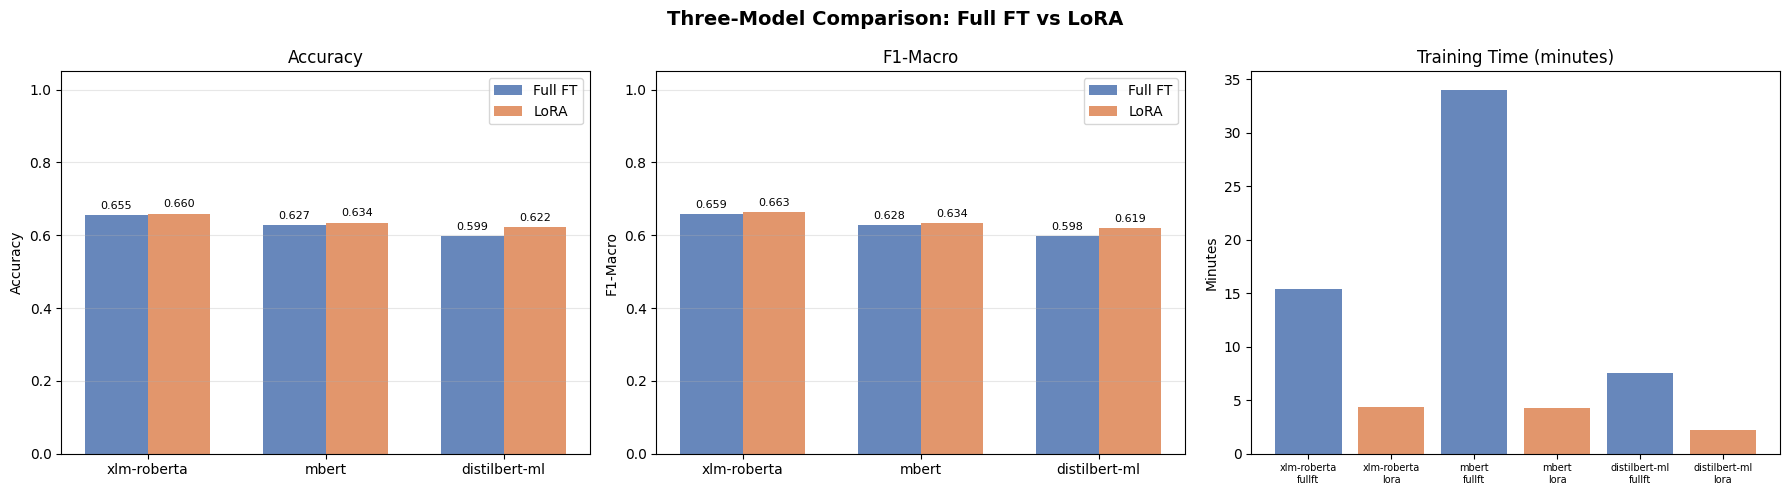

In [76]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Three-Model Comparison: Full FT vs LoRA",
             fontsize=14, fontweight="bold")

models  = list(MODELS.keys())
x       = np.arange(len(models))
width   = 0.35
palette = {"Full FT": "#4C72B0", "LoRA": "#DD8452"}

for ax, (metric_col, metric_label) in zip(
    axes[:2],
    [("eval_accuracy", "Accuracy"), ("eval_f1_macro", "F1-Macro")]
):
    for method, offset in zip(["Full FT", "LoRA"], [-width/2, width/2]):
        vals = [r['test_results'][metric_col]
                for r in all_results if r['method'] == method]
        bars = ax.bar(x + offset, vals, width,
                      label=method, color=palette[method], alpha=0.85)
        ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.set_ylim(0, 1.05)
    ax.set_title(metric_label)
    ax.set_ylabel(metric_label)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

# Training time
ax = axes[2]
time_labels = list(training_times.keys())
time_vals   = [v/60 for v in training_times.values()]
colors = ['#4C72B0' if 'fullft' in k else '#DD8452' for k in time_labels]
ax.bar(range(len(time_labels)), time_vals, color=colors, alpha=0.85)
ax.set_xticks(range(len(time_labels)))
ax.set_xticklabels(
    [k.replace('_', '\n') for k in time_labels], fontsize=7
)
ax.set_title("Training Time (minutes)")
ax.set_ylabel("Minutes")

plt.tight_layout()
plt.savefig("./outputs/three_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

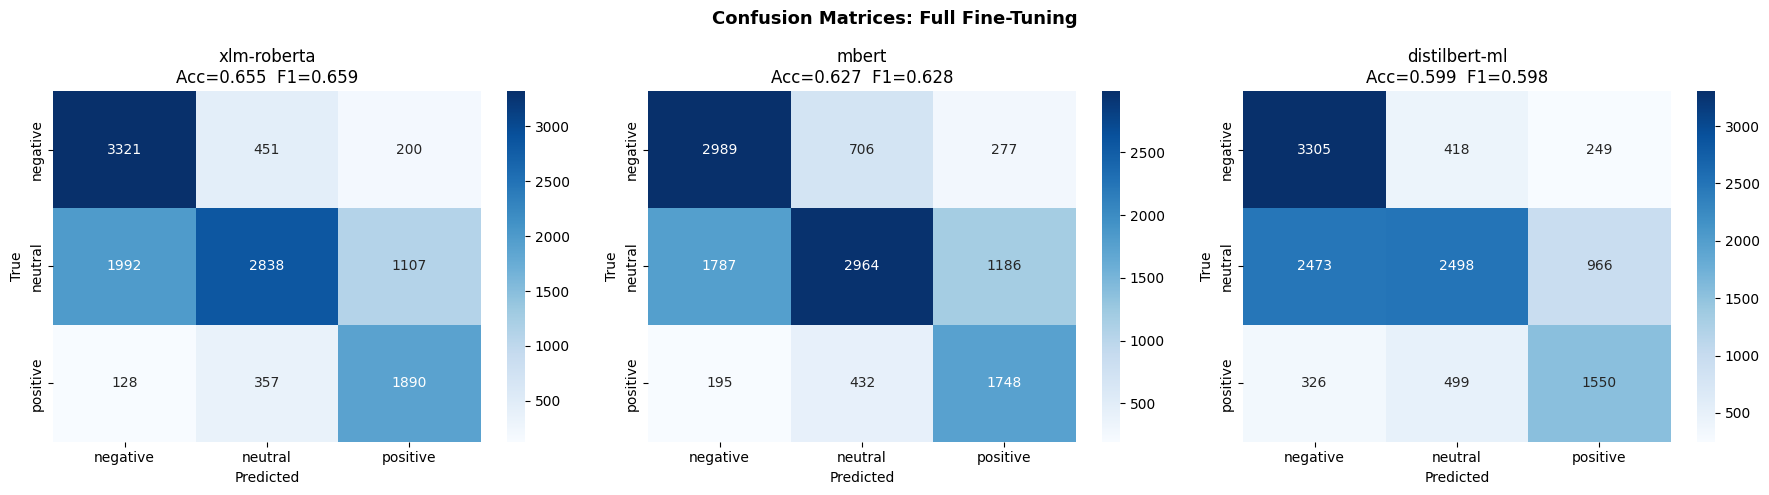

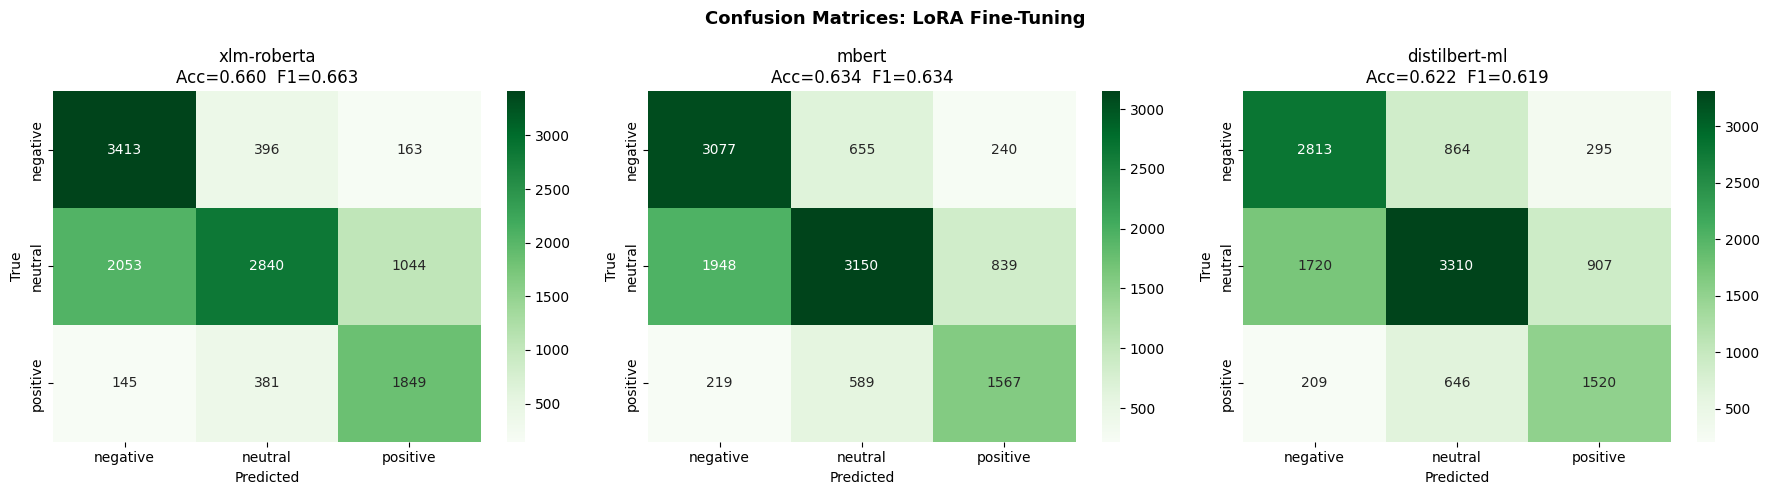

In [77]:
for method_filter, cmap, title_suffix in [
    ("Full FT", "Blues",  "Full Fine-Tuning"),
    ("LoRA",    "Greens", "LoRA Fine-Tuning"),
]:
    subset = [r for r in all_results if r['method'] == method_filter]
    if not subset:
        continue
    fig, axes = plt.subplots(1, len(subset), figsize=(6*len(subset), 5))
    if len(subset) == 1:
        axes = [axes]
    fig.suptitle(f"Confusion Matrices: {title_suffix}",
                 fontsize=13, fontweight="bold")
    for ax, r in zip(axes, subset):
        cm = confusion_matrix(r['true_ids'], r['pred_ids'])
        sns.heatmap(
            cm, annot=True, fmt='d', cmap=cmap,
            xticklabels=unique_labels,
            yticklabels=unique_labels, ax=ax,
        )
        ax.set_title(
            f"{r['model_key']}\n"
            f"Acc={r['test_results']['eval_accuracy']:.3f}  "
            f"F1={r['test_results']['eval_f1_macro']:.3f}"
        )
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
    plt.tight_layout()
    fname = method_filter.lower().replace(' ', '_')
    plt.savefig(f"./outputs/cm_{fname}.png", dpi=150, bbox_inches='tight')
    plt.show()

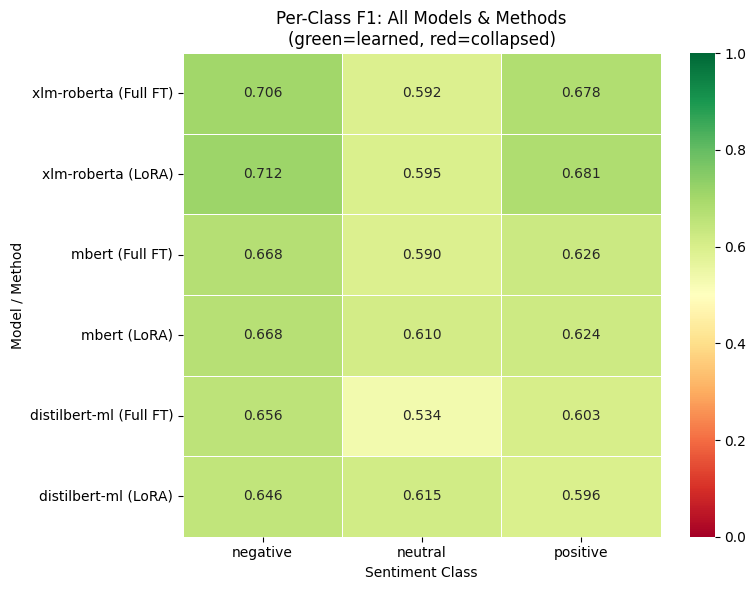

In [78]:
heatmap_data = {}
for r in all_results:
    key = f"{r['model_key']} ({r['method']})"
    heatmap_data[key] = f1_score(
        r['true_ids'], r['pred_ids'],
        labels=list(range(NUM_LABELS)),
        average=None, zero_division=0,
    )

heatmap_df = pd.DataFrame(heatmap_data, index=unique_labels).T

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    heatmap_df, annot=True, fmt='.3f', cmap='RdYlGn',
    vmin=0, vmax=1, linewidths=0.5, ax=ax,
)
ax.set_title("Per-Class F1: All Models & Methods\n(green=learned, red=collapsed)",
             fontsize=12)
ax.set_xlabel("Sentiment Class")
ax.set_ylabel("Model / Method")
plt.tight_layout()
plt.savefig("./outputs/per_class_f1_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## SHAP Analysis
SHAP assigns each token a contribution score toward the predicted class.  
Runs on **CPU** — MPS causes instability with SHAP masking loops.

In [79]:
import shap

# Pick best Full FT model
best_result = max(
    [r for r in all_results if r['method'] == 'Full FT'],
    key=lambda r: r['test_results']['eval_f1_macro'],
)
best_key  = best_result['model_key']
best_name = MODELS[best_key]
print(f"SHAP on: {best_key} (F1={best_result['test_results']['eval_f1_macro']:.4f})")

# Load fine-tuned checkpoint on CPU
_shap_path  = f"./outputs/{best_key}_fullft/best"
_shap_tok   = AutoTokenizer.from_pretrained(_shap_path)
_shap_model = AutoModelForSequenceClassification.from_pretrained(
    _shap_path
).to('cpu')
_shap_model.eval()

_shap_pipe = pipeline(
    task       = 'text-classification',
    model      = _shap_model,
    tokenizer  = _shap_tok,
    top_k      = None,
    device     = -1,
    truncation = True,
    max_length = MAX_LENGTH,
)

shap_samples, shap_true = [], []
for sentiment in unique_labels:
    subset = test_df[test_df['Sentiment'] == sentiment].head(3)
    shap_samples.extend(subset['Text'].tolist())
    shap_true.extend(subset['Sentiment'].tolist())

print(f"Running SHAP on {len(shap_samples)} samples...")

explainer   = shap.Explainer(
    _shap_pipe,
    algorithm    = 'partition',
    output_names = unique_labels,
)
shap_values = explainer(shap_samples)
print("SHAP done.")

SHAP on: xlm-roberta (F1=0.6588)


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 9275.04it/s]

Running SHAP on 9 samples...



PartitionExplainer explainer: 10it [01:21,  9.04s/it]                      

SHAP done.


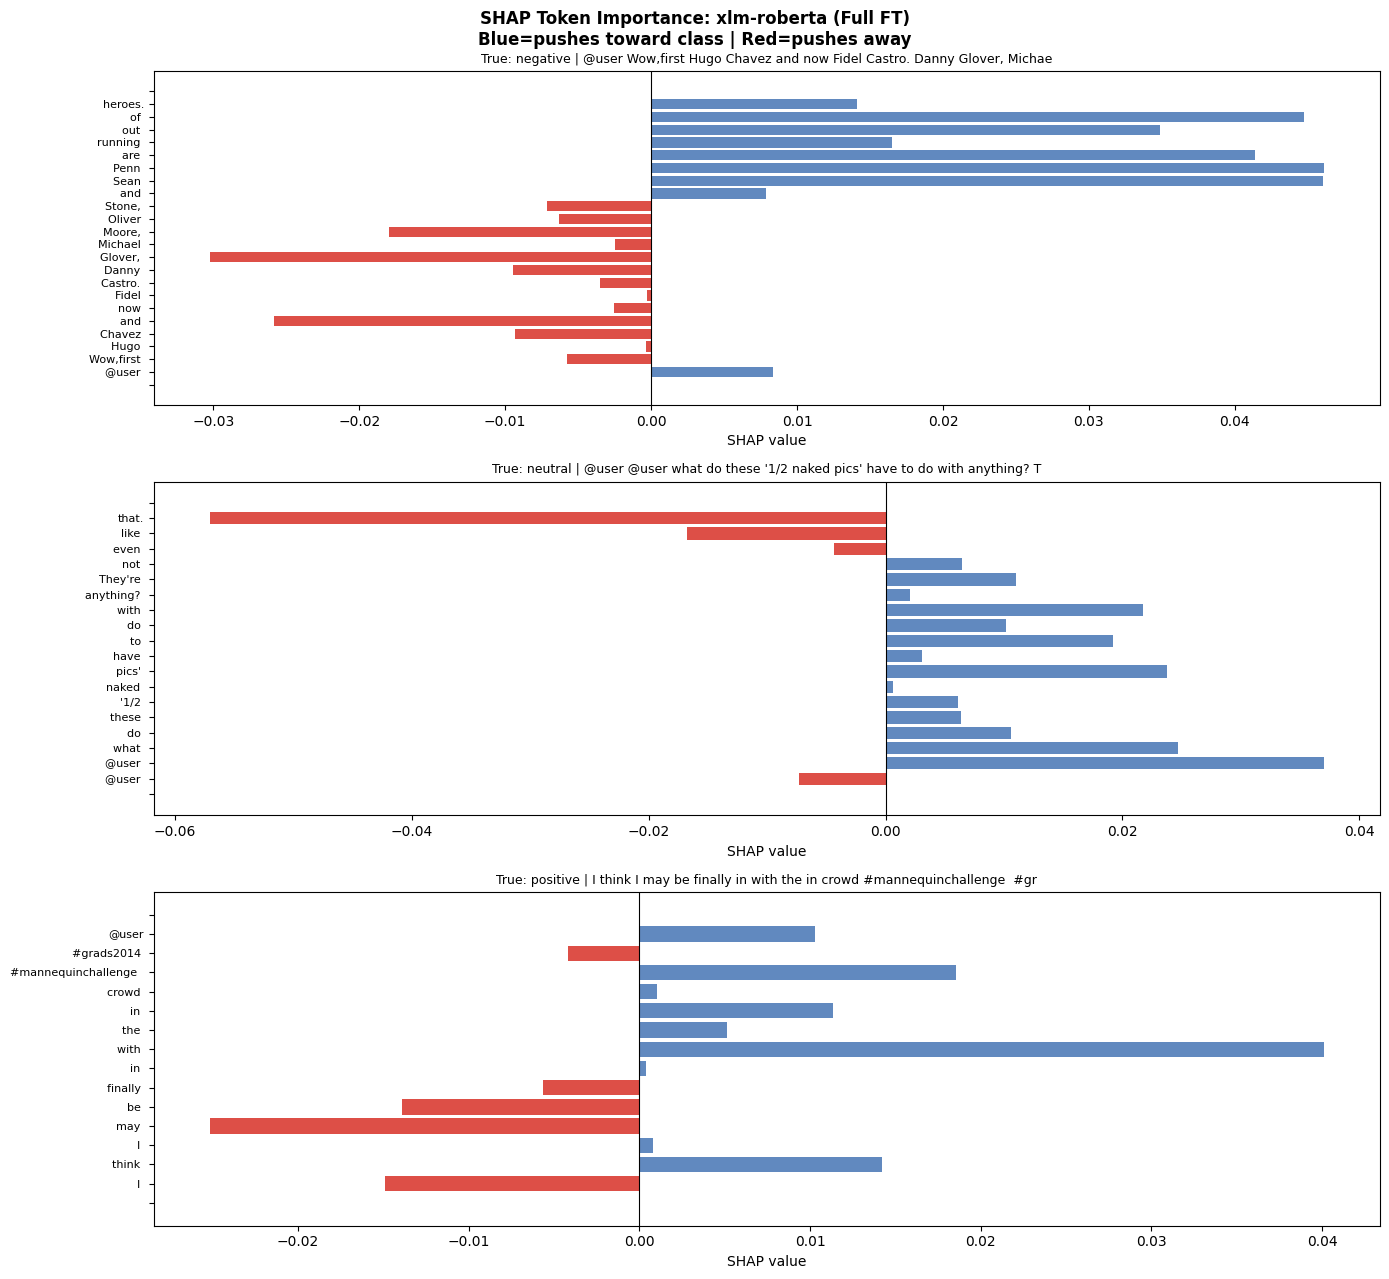

In [80]:
# Plot 1: Token importance bars per class
fig, axes = plt.subplots(3, 1, figsize=(14, 13))
fig.suptitle(
    f"SHAP Token Importance: {best_key} (Full FT)\n"
    "Blue=pushes toward class | Red=pushes away",
    fontsize=12, fontweight='bold'
)

for ax, label in zip(axes, unique_labels):
    idx = next(j for j, t in enumerate(shap_true) if t == label)
    class_idx = label2id[label]
    tokens = shap_values[idx].data
    values = shap_values[idx].values[:, class_idx]
    colors = ['#4575b4' if v >= 0 else '#d73027' for v in values]
    ax.barh(range(len(tokens)), values, color=colors, alpha=0.85)
    ax.set_yticks(range(len(tokens)))
    ax.set_yticklabels(tokens, fontsize=8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f"True: {label} | {shap_samples[idx][:70]}", fontsize=9)
    ax.set_xlabel('SHAP value')

plt.tight_layout()
plt.savefig("./outputs/shap_token_importance.png", dpi=150, bbox_inches="tight")
plt.show()

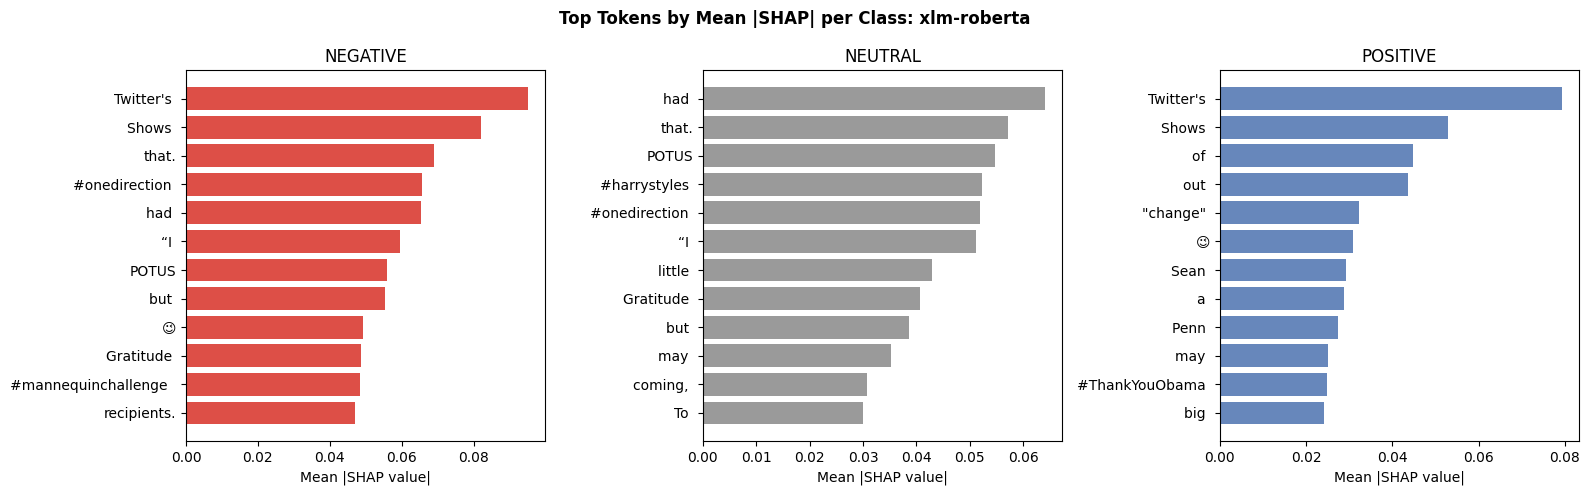

Saved: ./outputs/reports/shap_token_analysis.md


In [81]:
# Plot 2: Top tokens per class (global)
all_tokens, all_vals = [], []
for i in range(len(shap_samples)):
    all_tokens.extend(shap_values[i].data)
    all_vals.extend(shap_values[i].values)

token_df = pd.DataFrame(all_vals, columns=unique_labels)
token_df['token'] = all_tokens

special = {'<s>', '</s>', '<pad>', '[CLS]', '[SEP]', '[PAD]', chr(9601)}
token_df = token_df[~token_df['token'].isin(special)]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    f"Top Tokens by Mean |SHAP| per Class: {best_key}",
    fontsize=12, fontweight='bold'
)

for ax, label in zip(axes, unique_labels):
    top = (
        token_df.groupby('token')[label]
        .mean().abs()
        .sort_values(ascending=False)
        .head(12)
    )
    color = '#4C72B0' if label=='positive' else '#d73027' if label=='negative' else '#888888'
    ax.barh(top.index[::-1], top.values[::-1], color=color, alpha=0.85)
    ax.set_title(label.upper())
    ax.set_xlabel('Mean |SHAP value|')

plt.tight_layout()
plt.savefig("./outputs/shap_top_tokens.png", dpi=150, bbox_inches="tight")
plt.show()

# Save SHAP report as markdown
shap_md = '# SHAP Top Tokens per Class\n\n'
for label in unique_labels:
    top = (
        token_df.groupby('token')[label]
        .mean().abs()
        .sort_values(ascending=False)
        .head(10)
    )
    shap_md += f'## {label.upper()}\n\n'
    shap_md += '| Token | Mean |SHAP| |\n|-------|------------|\n'
    for tok, score in top.items():
        shap_md += f'| {tok} | {score:.4f} |\n'
    shap_md += '\n'

with open('./outputs/reports/shap_token_analysis.md', 'w') as f:
    f.write(shap_md)
print("Saved: ./outputs/reports/shap_token_analysis.md")

In [ ]:
# Log LLM summary table to WandB
if WANDB_ENABLED:
    wandb.init(
        project = WANDB_PROJECT,
        name    = "llm_summary",
        reinit  = True,
    )
    table = wandb.Table(
        dataframe=comparison_df[[
            "Model", "Method", "Accuracy", "F1-Macro", "Loss", "Train Time(m)"
        ]]
    )
    wandb.log({"LLM Results Table": table})
    wandb.finish()
    print(f"Results logged to WandB project: {WANDB_PROJECT}")
else:
    print("WandB not enabled. Results in ./outputs/reports/")

Results logged to WandB project: sentiment-analysis-bert
